Setting QUAD:IN20:525:BCTRL to -10.0
Setting QUAD:IN20:525:BCTRL to -5.0
Setting QUAD:IN20:525:BCTRL to 0.0
Setting QUAD:IN20:525:BCTRL to 5.0
Setting QUAD:IN20:525:BCTRL to 10.0


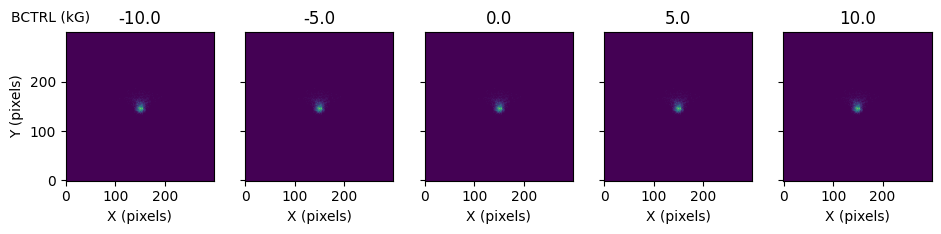

In [ ]:
from virtual_accelerator.models.staged_model import get_cu_hxr_staged_model
import matplotlib.pyplot as plt
import numpy as np

model = get_cu_hxr_staged_model(
    track_beam=True, start_element="OTR2", end_element="OTR4", n_particles=10000
)

# do a quadrupole scan using QUAD:IN20:525:BCTRL and plot the beam distribution at OTR4
OTR_IMAGE_PV = "OTRS:IN20:711:Image:ArrayData"
SCAN_QUAD_PV = "QUAD:IN20:525:BCTRL"

quad_values = np.linspace(-10, 10, 5)
fig, ax = plt.subplots(1, len(quad_values), sharex=True, sharey=True)
images = []
for i, quad_value in enumerate(quad_values):
    print(f"Setting {SCAN_QUAD_PV} to {quad_value:.1f}")
    model.set({SCAN_QUAD_PV: quad_value})
    image = model.get(OTR_IMAGE_PV)
    images.append(image)

images = np.array(images)
max_value = np.max(images)

# plot the images - zoomed in on the center 300x300 pixels
for i, (quad_value, image) in enumerate(zip(quad_values, images)):
    width = 300
    image = image[
        images.shape[1] // 2 - width // 2 : images.shape[1] // 2 + width // 2,
        images.shape[2] // 2 - width // 2 : images.shape[2] // 2 + width // 2,
    ]

    ax[i].imshow(
        image,
        rasterized=True,
        origin="lower",
    )
    ax[i].set_title(f"{quad_value:.1f}")
    ax[i].set_xlabel("X (pixels)")
    if i == 0:
        ax[i].set_ylabel("Y (pixels)")

# add label for quad strengths
ax[0].text(
    -0.1,
    1.05,
    "BCTRL (kG)",
    transform=ax[0].transAxes,
    ha="center",
    va="bottom",
)

plt.tight_layout()
fig.set_size_inches(10, 3)
fig.savefig("quad_scan.png", dpi=300)
fig.savefig("quad_scan.svg", dpi=300)

In [ ]:
model.set({"QUAD:IN20:631:BCTRL": 6.0})
model.supported_variables.keys()

dict_keys(['CAMR:IN20:186:R_DIST', 'Pulse_length', 'FBCK:BCI0:1:CHRG_S', 'SOLN:IN20:121:BCTRL', 'QUAD:IN20:121:BCTRL', 'QUAD:IN20:122:BCTRL', 'ACCL:IN20:300:L0A_ADES', 'ACCL:IN20:300:L0A_PDES', 'ACCL:IN20:400:L0B_ADES', 'ACCL:IN20:400:L0B_PDES', 'QUAD:IN20:361:BCTRL', 'QUAD:IN20:371:BCTRL', 'QUAD:IN20:425:BCTRL', 'QUAD:IN20:441:BCTRL', 'QUAD:IN20:511:BCTRL', 'QUAD:IN20:525:BCTRL', 'OTRS:IN20:571:XRMS', 'OTRS:IN20:571:YRMS', 'sigma_z', 'norm_emit_x', 'norm_emit_y', 'QUAD:IN20:631:BCTRL', 'QUAD:IN20:651:BCTRL', 'XCOR:IN20:641:BCTRL', 'YCOR:IN20:642:BCTRL', 'OTRS:IN20:621:Image:ArrayData', 'OTRS:IN20:621:Image:ArraySize1_RBV', 'OTRS:IN20:621:Image:ArraySize0_RBV', 'OTRS:IN20:621:RESOLUTION', 'OTRS:IN20:711:Image:ArrayData', 'OTRS:IN20:711:Image:ArraySize1_RBV', 'OTRS:IN20:711:Image:ArraySize0_RBV', 'OTRS:IN20:711:RESOLUTION', 'name', 'ix_ele', 'ix_branch', 'a.beta', 'a.alpha', 'a.eta', 'a.etap', 'a.gamma', 'a.phi', 'b.beta', 'b.alpha', 'b.eta', 'b.etap', 'b.gamma', 'b.phi', 'l', 'e_tot', 

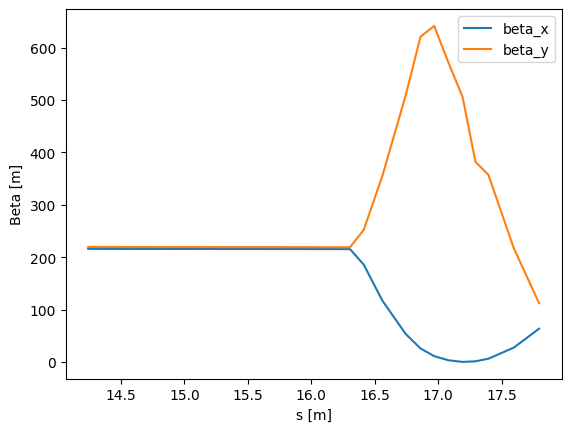

In [ ]:
fig, ax = plt.subplots()
info = model.get(["s", "x.beta", "y.beta"])
ax.plot(info["s"], info["x.beta"], label="beta_x")
ax.plot(info["s"], info["y.beta"], label="beta_y")
ax.set_xlabel("s [m]")
ax.set_ylabel("Beta [m]")
ax.legend()
plt.show()